In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [44]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [45]:
df.shape

(5000, 13)

In [46]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [47]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [48]:
df.duplicated().sum()

np.int64(2)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [50]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

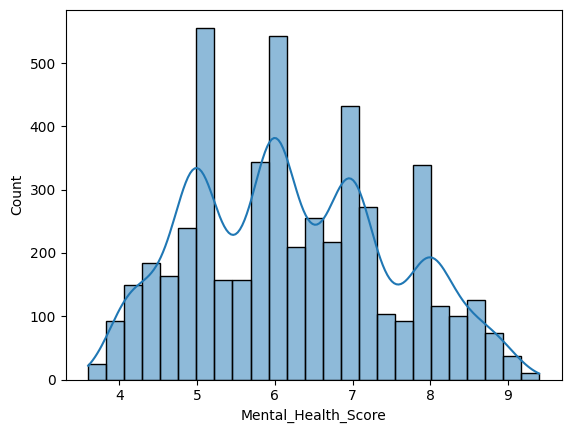

In [51]:
sns.histplot(df['Mental_Health_Score'], kde=True)

<Axes: >

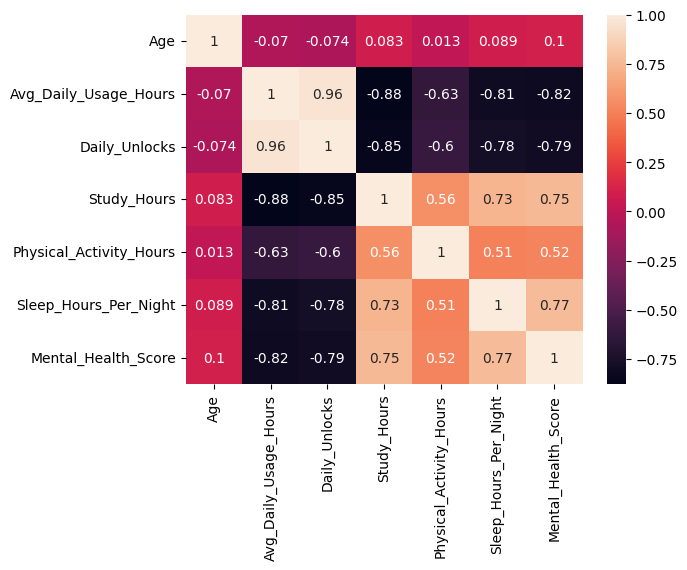

In [52]:
# which numeric features move together with the target
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [53]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

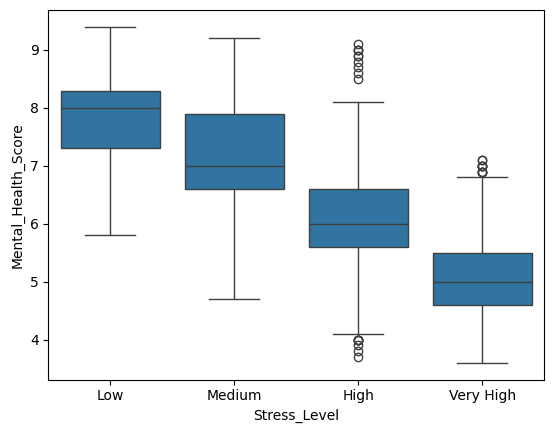

In [54]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

<Axes: xlabel='Mental_Health_Score', ylabel='Avg_Daily_Usage_Hours'>

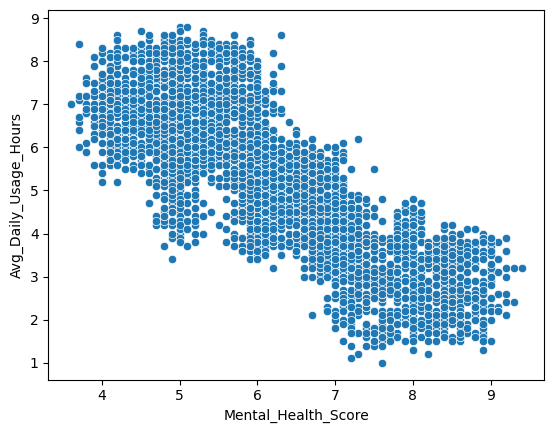

In [55]:
sns.scatterplot(x=df['Mental_Health_Score'], y=df['Avg_Daily_Usage_Hours'], data=df)

<Axes: xlabel='Mental_Health_Score', ylabel='Sleep_Hours_Per_Night'>

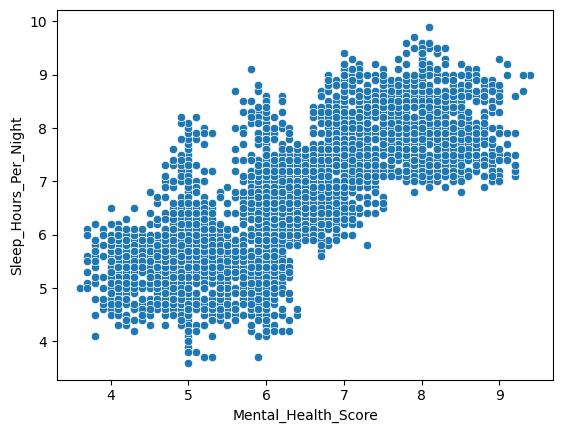

In [56]:
sns.scatterplot(x=df['Mental_Health_Score'], y=df['Sleep_Hours_Per_Night'], data=df)

In [57]:
df['Most_Used_Platform'].unique()

array(['Facebook', 'LinkedIn', 'Instagram', 'Snapchat', 'Twitter',
       'YouTube', 'TikTok', 'LINE', 'KakaoTalk', 'VKontakte', 'WhatsApp',
       'WeChat'], dtype=object)

In [58]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


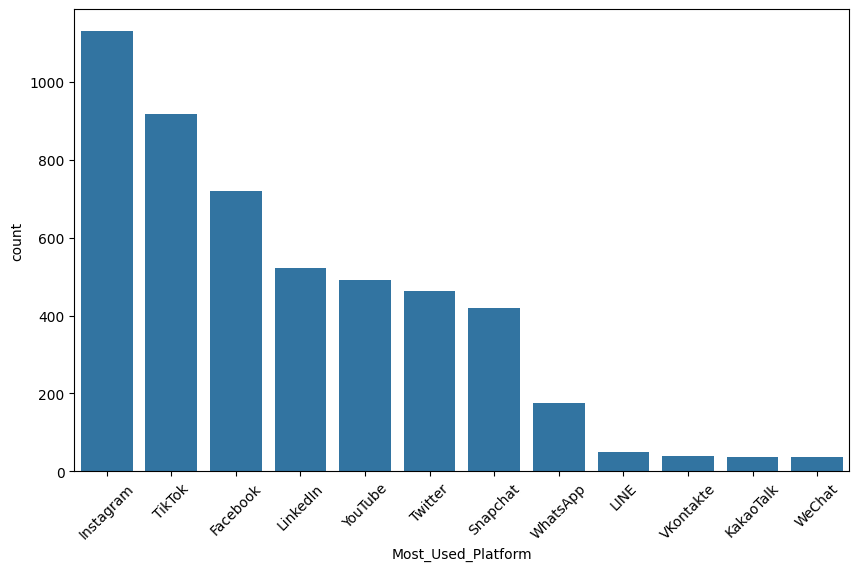

In [59]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=45)
plt.show()

In [60]:
new_features = df.select_dtypes(include='number')
new_features.head()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4


In [61]:
Q1 = new_features.quantile(0.25)
Q3 = new_features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ((new_features < (Q1 - 1.5 * IQR)) | (new_features > (Q3 + 1.5 * IQR)))
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [62]:
df = df.drop_duplicates()

In [63]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [64]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [65]:
num_col = df.select_dtypes(include='number')
num_col.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [66]:
top_countires = df['Country'].value_counts().index[:10].tolist()
top_countires

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [67]:
def grouped_countries (country):
  if country in top_countires:
    return country
  else:
    return 'Others'

In [68]:
df['gourped_countries'] = df['Country'].apply(grouped_countries)

In [69]:
df['gourped_countries'].value_counts()

,count
gourped_countries,
Other,1879
Others,1352
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94


In [70]:
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

skewed_col   =   ['Study_Hours']
numeric_col  = 	 ['Age',	'Avg_Daily_Usage_Hours',	'Daily_Unlocks', 'Physical_Activity_Hours',	'Sleep_Hours_Per_Night']
ordinal_col  =   ['Stress_Level']
normal_col   =   ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "gourped_countries"]

feature_col = skewed_col + numeric_col + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [71]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# skewed
skewed_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# numeric
plain_numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

# normal
normal_pipeline = Pipeline(steps=[
  ('encode', OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(transformers=[
    ('skewed', skewed_pipeline, skewed_col),
    ('numeric', plain_numeric_pipeline, numeric_col),
    ('ordinal', ordinal_pipeline, ordinal_col),
    ('normal', normal_pipeline, normal_col)
])



In [85]:
# baseline regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_y_pred = lr_pipeline.predict(X_test)
y_pred_train = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_y_pred)
lr_r2_training = r2_score(y_train, y_pred_train)
lr_mae = mean_absolute_error(y_test, lr_y_pred)


print(f"r2_testing: {lr_r2_testing}")
print(f"r2_training: {lr_r2_training}")
print(f"mae_testing: {lr_mae}")





r2_testing: 0.7446750207322383
r2_training: 0.7318991298307536
mae_testing: 0.5364273713851445


In [86]:
from numpy.random import RandomState
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_pred_train = rf_pipeline.predict(X_train)

r2_testing = r2_score(y_test, y_pred)
rf_r2_training = r2_score(y_train, y_pred_train)
rf_mae = mean_absolute_error(y_test, y_pred)

print(f"r2_testing: {r2_testing}")
print(f"r2_training: {rf_r2_training}")
print(f"mae_testing: {rf_mae}")


r2_testing: 0.889749781867271
r2_training: 0.9821441426821711
mae_testing: 0.32605846666666694


In [74]:
#  hyperparamter tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skewed',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('numeric',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Physical_Activi...
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'gourped_countries'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, verbose=2)

In [75]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 10,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [77]:
rf_best_pipeline = random_search.best_estimator_
rf_best_pred = rf_pipeline.predict(X_test)
r2_testing = r2_score(y_test, rf_best_pred)
Mae = mean_absolute_error(y_test, rf_best_pred )

print(f"r2 score after Hyperparameter tuning : ", r2_testing)
print(f"mae : ", Mae )


r2 score after Hyperparameter tuning :  0.889749781867271
mae :  0.32605846666666694


## Model Evaluation

In [87]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_y_pred))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.744675     0.731899  0.536427  0.669662
1  Random Forest (default)  0.889750     0.982144  0.326058  0.440047
2    Random Forest (tuned)  0.870358     0.940038  0.360343  0.477180


## Save the model

In [88]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']